# Phase 2: Traditional ML — TF-IDF + Linear SVM

This notebook implements the Aletras et al. (2016) baseline: **TF-IDF + Linear SVM** applied to ECHR judgment **FACTS sections only**, for **Article 6** cases.

The label is **Article-6-specific**: was Article 6 found violated (`1`) or not (`0`)?

Two evaluation settings are used:
- **Random split** (75/25 stratified) — standard baseline
- **Temporal split** — train on older cases, test on newer cases (tests for temporal generalization)

## 1. Setup

In [1]:
%matplotlib inline
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords

for pkg_path, pkg_name in [
    ('corpora/stopwords', 'stopwords'),
    ('corpora/wordnet',   'wordnet'),
    ('corpora/omw-1.4',  'omw-1.4'),
]:
    try:
        nltk.data.find(pkg_path)
    except LookupError:
        nltk.download(pkg_name)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/leondgarse/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/leondgarse/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Legal Tokenizer

Ported from the EDA notebook's shared lexical preprocessing pipeline.
Applies the same lemmatization and stopword filtering used in the Phase 1 TF-IDF analysis,
so that features are directly comparable across both phases.

Key steps:
- Manual lemma map for common irregular plurals in legal text (e.g. *authorities → authority*)
- WordNet lemmatizer with noun POS — normalises singular/plural noun forms
- Extended stopword list: NLTK English + legal boilerplate terms (`court`, `case`, `mr`, `mrs`, `ms`)

In [2]:
wnl = WordNetLemmatizer()

LEGAL_EXTRA_STOPWORDS = {"mr", "mrs", "ms", "court", "case"}
BASE_STOPWORDS        = set(nltk_stopwords.words("english"))
ALL_STOPWORDS         = BASE_STOPWORDS | LEGAL_EXTRA_STOPWORDS

MANUAL_LEMMA_MAP = {
    "applicants":   "applicant",
    "authorities":  "authority",
    "proceedings":  "proceeding",
    "judges":       "judge",
    "lawyers":      "lawyer",
    "officers":     "officer",
    "children":     "child",
    "women":        "woman",
    "men":          "man",
}

def normalize_token(tok: str) -> str:
    tok = tok.lower().strip()
    tok = MANUAL_LEMMA_MAP.get(tok, tok)
    if not re.search(r"[a-z]", tok):
        return ""
    # Noun POS prioritises singular/plural normalisation
    tok = wnl.lemmatize(tok, pos="n")
    return tok

def legal_tokenizer(text: str):
    text   = str(text).lower()
    tokens = re.findall(r"[a-z']+", text)
    tokens = [normalize_token(t) for t in tokens]
    tokens = [t for t in tokens if t and len(t) > 2 and t not in ALL_STOPWORDS]
    return tokens

# Quick sanity check
sample = "The applicants' lawyers filed proceedings before the authorities."
print(legal_tokenizer(sample))

["applicants'", 'lawyer', 'filed', 'proceeding', 'authority']


## 3. Load & Filter Data

In [3]:
df_all = pd.read_csv('data/processed/processed.csv')
print(f'Full dataset: {len(df_all)} cases')
df_all.head(2)

Full dataset: 952 cases


,text,label,item_id,respondent,violation_articles,nonviolation_articles,year
0,I. THE CIRCUMSTANCES OF THE CASE4. The applicants are:1) Ms Bilat Akhmatkhanova_ who was born in 1956_2) Mr Sharpudi...,1,001-100029,RUS,3;5,NaN,2010
1,I. THE CIRCUMSTANCES OF THE CASE5. The applicants were born in 1962 and 1967 respectively and are now serving their ...,1,001-100040,RUS,5;6,NaN,2010


In [4]:
def contains_article(series, article='6'):
    """Return boolean mask: rows where `article` appears in a semicolon-delimited column."""
    return series.astype(str).str.split(';').apply(lambda arts: article in arts)

art6_violated    = contains_article(df_all['violation_articles'],    '6')
art6_notviolated = contains_article(df_all['nonviolation_articles'], '6')

# Keep only cases where Article 6 was adjudicated (either way)
df = df_all[art6_violated | art6_notviolated].copy()

# Article-6-specific label: 1 = Art 6 violated, 0 = Art 6 not violated
# Cases appearing in both columns (partial sub-article violation) are labelled as violation
df['label_art6'] = art6_violated[df.index].astype(int)

print(f'Article 6 cases: {len(df)}')
print(f'Label distribution:\n{df["label_art6"].value_counts().rename({1: "Violation", 0: "No violation"})}')

Article 6 cases: 436
Label distribution:
label_art6
Violation       320
No violation    116
Name: count, dtype: int64


In [5]:
print('Year range:', df['year'].min(), '–', df['year'].max())
print()
print('Cases by respondent:')
print(df.groupby('respondent')['label_art6'].value_counts().unstack(fill_value=0)
        .rename(columns={0: 'No violation', 1: 'Violation'}))

Year range: 1983 – 2026

Cases by respondent:
label_art6  No violation  Violation
respondent                         
GBR                   52         96
RUS                   39        128
TUR                   25         96


## 4. TF-IDF Feature Extraction

Features are extracted from the **FACTS section only** using the `legal_tokenizer` defined above — the same pipeline as the Phase 1 EDA, ensuring consistency.

Parameters:
- `min_df=3`: term must appear in at least 3 documents (`min_df=50` from the reference repo is too aggressive for ~430 cases)
- `max_df=0.90`: drop near-universal terms
- `sublinear_tf=True`: log-scale term frequency, standard for SVM text classification
- `ngram_range=(1, 2)`: unigrams + bigrams

In [6]:
def make_tfidf():
    """Return a TfidfVectorizer using the shared legal_tokenizer."""
    return TfidfVectorizer(
        tokenizer=legal_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,       # legal_tokenizer already lowercases
        min_df=3,
        max_df=0.90,
        sublinear_tf=True,
        ngram_range=(1, 2),
    )

X = df['text'].values
y = df['label_art6'].values

# Fit on full corpus just to inspect vocabulary size
_v = make_tfidf().fit(X)
print(f'Vocabulary size: {len(_v.vocabulary_):,} n-grams')

Vocabulary size: 16,681 n-grams


## 5. Evaluation Setting A — Random Split (75/25)

In [19]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {len(X_train_r)}  |  Test: {len(X_test_r)}')

# Try C=0.1 or C=0.5 — smaller C = more regularisation, often better on small datasets
pipeline_random = Pipeline([
    ('tfidf', make_tfidf()),
    ('svm',   LinearSVC(C=0.5, max_iter=2000, random_state=RANDOM_STATE)),
])

pipeline_random.fit(X_train_r, y_train_r)
y_pred_r = pipeline_random.predict(X_test_r)

print('\n=== Random Split — Classification Report ===')
print(classification_report(y_test_r, y_pred_r, target_names=['No Violation', 'Violation']))

Train: 327  |  Test: 109

=== Random Split — Classification Report ===
              precision    recall  f1-score   support

No Violation       0.67      0.21      0.32        29
   Violation       0.77      0.96      0.86        80

    accuracy                           0.76       109
   macro avg       0.72      0.58      0.59       109
weighted avg       0.74      0.76      0.71       109



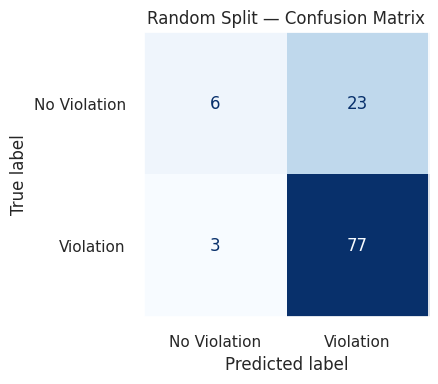

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_r, y_pred_r)
ConfusionMatrixDisplay(cm, display_labels=['No Violation', 'Violation']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Split — Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Evaluation Setting B — Temporal Split

Train on cases before the split year, test on cases from that year onwards.
This tests whether the model generalises to future cases or overfits to era-specific language.

The split year is chosen as the 75th percentile of judgment years, giving approximately the same 75/25 proportion as the random split.

In [9]:
split_year = int(np.percentile(df['year'].dropna(), 75))
print(f'Temporal split year: {split_year}')
print(f'  Train (< {split_year}): {(df["year"] < split_year).sum()} cases')
print(f'  Test  (≥ {split_year}): {(df["year"] >= split_year).sum()} cases')

Temporal split year: 2012
  Train (< 2012): 278 cases
  Test  (≥ 2012): 158 cases


In [17]:
train_mask = df['year'] < split_year
test_mask  = df['year'] >= split_year

X_train_t = df.loc[train_mask, 'text'].values
y_train_t  = df.loc[train_mask, 'label_art6'].values
X_test_t   = df.loc[test_mask,  'text'].values
y_test_t   = df.loc[test_mask,  'label_art6'].values

pipeline_temporal = Pipeline([
    ('tfidf', make_tfidf()),
    ('svm',   LinearSVC(C=0.5, max_iter=2000, random_state=RANDOM_STATE)),
])

pipeline_temporal.fit(X_train_t, y_train_t)
y_pred_t = pipeline_temporal.predict(X_test_t)

print(f'=== Temporal Split (train < {split_year}, test ≥ {split_year}) — Classification Report ===')
print(classification_report(y_test_t, y_pred_t, target_names=['No Violation', 'Violation']))

=== Temporal Split (train < 2012, test ≥ 2012) — Classification Report ===
              precision    recall  f1-score   support

No Violation       0.67      0.08      0.14        52
   Violation       0.68      0.98      0.81       106

    accuracy                           0.68       158
   macro avg       0.68      0.53      0.47       158
weighted avg       0.68      0.68      0.59       158



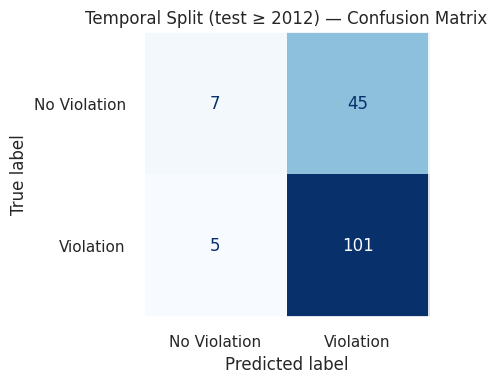

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_t = confusion_matrix(y_test_t, y_pred_t)
ConfusionMatrixDisplay(cm_t, display_labels=['No Violation', 'Violation']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Temporal Split (test ≥ {split_year}) — Confusion Matrix')
plt.tight_layout()
plt.show()

## 7. Bias Analysis — Per-Country Performance

If the model exploits country-level spurious correlations, performance should vary significantly across respondent states.

In [12]:
# Reconstruct test-set indices (same seed as the split above)
indices = np.arange(len(df))
_, test_idx = train_test_split(indices, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

test_df = df.iloc[test_idx].copy()
test_df['predicted'] = y_pred_r
test_df['correct']   = (test_df['predicted'] == test_df['label_art6']).astype(int)

country_stats = test_df.groupby('respondent').agg(
    n_cases=('correct', 'count'),
    accuracy=('correct', 'mean'),
    violation_rate=('label_art6', 'mean'),
).round(3)

print('Per-country accuracy on test set (random split):')
display(country_stats)

Per-country accuracy on test set (random split):


,n_cases,accuracy,violation_rate
respondent,,,
GBR,44,0.659,0.659
RUS,38,0.816,0.763
TUR,27,0.852,0.815


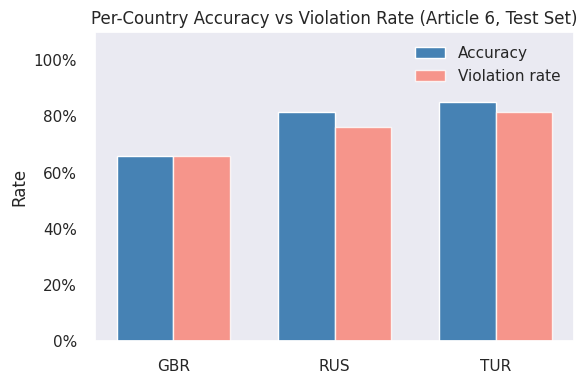

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
countries = country_stats.index.tolist()
x = np.arange(len(countries))
width = 0.35

ax.bar(x - width/2, country_stats['accuracy'],       width, label='Accuracy',       color='steelblue')
ax.bar(x + width/2, country_stats['violation_rate'], width, label='Violation rate', color='salmon', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Per-Country Accuracy vs Violation Rate (Article 6, Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Top Discriminating Features

LinearSVC learns a weight vector: the highest positive weights indicate terms most associated with **violation**, the most negative with **no violation**.
Presence of country names or procedural boilerplate here is direct evidence of spurious correlation.

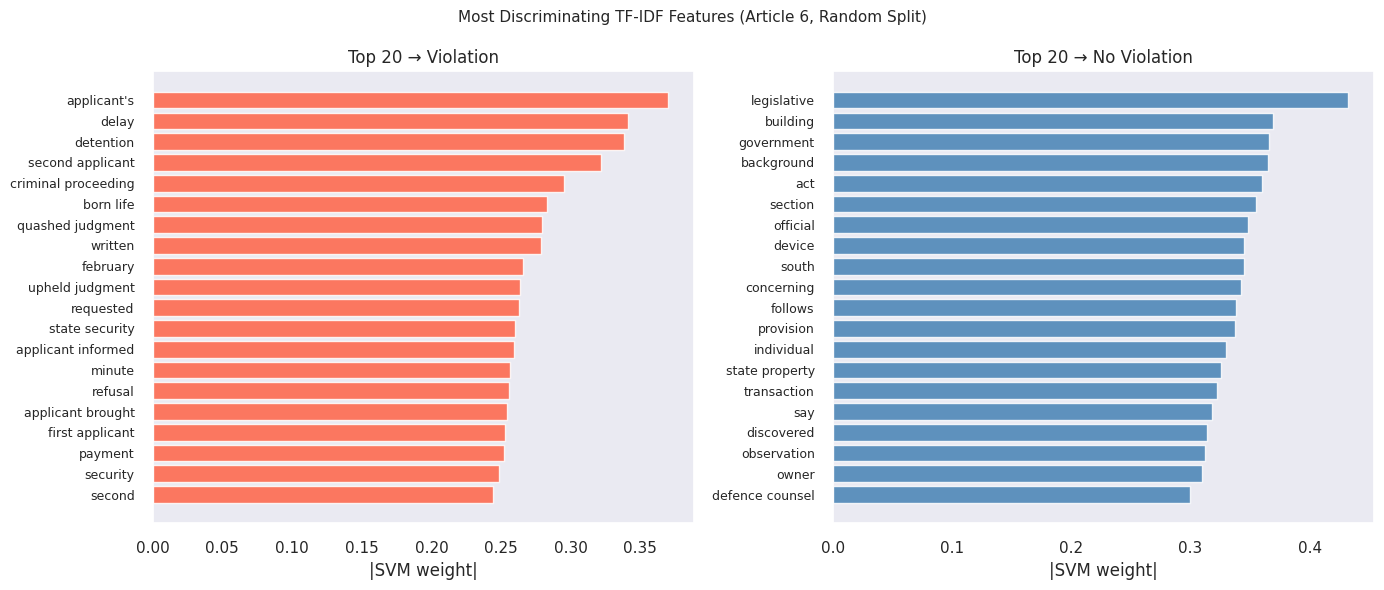

In [14]:
feature_names = np.array(pipeline_random.named_steps['tfidf'].get_feature_names_out())
coef          = pipeline_random.named_steps['svm'].coef_[0]

N = 20
top_pos_idx = np.argsort(coef)[-N:][::-1]   # violation
top_neg_idx = np.argsort(coef)[:N]           # no violation

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, title, color in [
    (axes[0], top_pos_idx, f'Top {N} → Violation',    'tomato'),
    (axes[1], top_neg_idx, f'Top {N} → No Violation', 'steelblue'),
]:
    terms  = feature_names[idx]
    values = np.abs(coef[idx])
    ax.barh(range(N), values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(N))
    ax.set_yticklabels(terms[::-1], fontsize=9)
    ax.set_xlabel('|SVM weight|')
    ax.set_title(title)

plt.suptitle('Most Discriminating TF-IDF Features (Article 6, Random Split)', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Summary

| Setting | Notes |
|---|---|
| Random split | Standard i.i.d. evaluation; likely optimistic |
| Temporal split | Tests generalisation to future cases; expected performance drop |

**Interpretation guide:**
- A large gap between random-split and temporal-split accuracy suggests the model learns era-specific language rather than legal principles.
- High per-country variance in accuracy — especially accuracy closely tracking the violation rate — suggests the model exploits class base rates rather than case facts.
- Presence of procedural/boilerplate terms or country names in the top features confirms spurious correlation concerns.